NBA SHOT-PREDICTION SEASON 2014-2015
Analyzing & Predicting NBA Shots Using Machine Learning models.

In [6]:
import os

#HOME_DIR = '/Users/yoav/Documents/Yoav/CS/20936 - DS Project/Shotpred'
HOME_DIR = '/Users/home/Shotpred'

DATA_DIR = os.path.join(HOME_DIR, 'data')
EXT_DATA_DIR = os.path.join(DATA_DIR, 'External')
INT_DATA_DIR = os.path.join(DATA_DIR, 'Internal')

import sys
#sys.path.append("/Users/yoav/Documents/Yoav/CS/20936 - DS Project/Shotpred/utils")
sys.path.append("/Users/home/Shotpred/utils")


In [7]:
import pandas as pd
import os
from nba_api.stats.endpoints import playerindex, playbyplayv3

import data_utils as du

import importlib
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
import matplotlib.pyplot as plt


In [8]:
KAGGLE_SHOT_LOGS_201415_FILENAME = 'kaggle_shot_logs_2014_15.csv'
KAGGLE_SHOT_LOGS_201415_FULLPATH = os.path.join(EXT_DATA_DIR, KAGGLE_SHOT_LOGS_201415_FILENAME)

GENERAL_SHOT_LOGS_FILENAME = 'nba_2015_shots.csv'
GENERAL_SHOT_LOGS_FULLPATH = os.path.join(EXT_DATA_DIR, GENERAL_SHOT_LOGS_FILENAME)

In [9]:
KAGGLE_COLS_FOR_MERGE = ['GAME_ID', 'SHOT_CLOCK', 'DRIBBLES', 'TOUCH_TIME', 'CLOSEST_DEFENDER', 'CLOSEST_DEFENDER_PLAYER_ID', 'CLOSE_DEF_DIST', 'player_id', 'absolute_game_time']


In [10]:
shot_logs_1415 = pd.read_csv(KAGGLE_SHOT_LOGS_201415_FULLPATH)

In [11]:
active_players_201415_ids = shot_logs_1415['player_id'].unique()

In [12]:
shot_logs_1415['absolute_game_time'] = shot_logs_1415.apply(lambda row: du.clock_to_absolute_seconds(row['GAME_CLOCK'], row['PERIOD']), axis=1)

In [13]:
#active_players_career_stats = du.gather_mul_career_stats(active_players_201415_ids) # get the career stats for all active players in 2014-15 season

In [14]:
#active_players_cs_in_1415 = active_players_career_stats[active_players_career_stats['SEASON_ID'] == '2014-15'].reset_index(drop=True)
#active_players_cs_in_1415.to_csv(INT_DATA_DIR + 'active_players_career_stats_2014_15.csv', index=False)

In [15]:
active_players_cs_in_1415 = pd.read_csv(os.path.join(INT_DATA_DIR, 'active_players_career_stats_2014_15.csv'))

In [16]:
gen_sl = pd.read_csv(GENERAL_SHOT_LOGS_FULLPATH)

In [17]:
gen_sl['absolute_game_time'] = gen_sl.apply(lambda row: du.clock_to_absolute_seconds(f"{str(row["MINS_LEFT"]).zfill(2)}:{str(row["SECS_LEFT"]).zfill(2)}", row['QUARTER']), axis=1)

In [18]:
kaggle_for_join = shot_logs_1415[KAGGLE_COLS_FOR_MERGE]

In [19]:
kaggle_for_join.head()

,GAME_ID,SHOT_CLOCK,DRIBBLES,TOUCH_TIME,CLOSEST_DEFENDER,CLOSEST_DEFENDER_PLAYER_ID,CLOSE_DEF_DIST,player_id,absolute_game_time
0,21400899,10.8,2,1.9,"Anderson, Alan",101187,1.3,203148,651.0
1,21400899,3.4,0,0.8,"Bogdanovic, Bojan",202711,6.1,203148,706.0
2,21400899,NaN,3,2.7,"Bogdanovic, Bojan",202711,0.9,203148,720.0
3,21400899,10.3,2,1.9,"Brown, Markel",203900,3.4,203148,733.0
4,21400899,10.9,2,2.7,"Young, Thaddeus",201152,1.1,203148,806.0


In [20]:
gen_sl_game_ids = set(gen_sl['GAME_ID'].unique())
kaggle_for_join_game_ids = set(kaggle_for_join['GAME_ID'].unique())

common_game_ids = gen_sl_game_ids.intersection(kaggle_for_join_game_ids)

print(f"Number of unique GAME_IDs in gen_sl: {len(gen_sl_game_ids)}")
print(f"Number of unique GAME_IDs in kaggle_for_join: {len(kaggle_for_join_game_ids)}")
print(f"Number of common GAME_IDs in both: {len(common_game_ids)}")

Number of unique GAME_IDs in gen_sl: 1230
Number of unique GAME_IDs in kaggle_for_join: 904
Number of common GAME_IDs in both: 904


In [21]:
kaggle_for_join = kaggle_for_join.sort_values(by=['absolute_game_time']).reset_index(drop=True)

In [22]:
gen_sl = gen_sl.sort_values(by=['absolute_game_time']).reset_index(drop=True)
gen_sl['gen_sl_time_copy'] = gen_sl['absolute_game_time']

In [23]:
merged = pd.merge_asof(kaggle_for_join, gen_sl, on='absolute_game_time',left_by=['player_id', 'GAME_ID'], right_by=['PLAYER_ID', 'GAME_ID'],  direction='nearest', suffixes=['_kaggle', '_shot_logs'], tolerance=5) #,left_by=['player_id', 'GAME_ID'], right_by=['PLAYER_ID', 'GAME_ID'], 

In [24]:
merged

,GAME_ID,SHOT_CLOCK,DRIBBLES,TOUCH_TIME,CLOSEST_DEFENDER,CLOSEST_DEFENDER_PLAYER_ID,CLOSE_DEF_DIST,player_id,absolute_game_time,SEASON_1,...,ZONE_NAME,ZONE_ABB,ZONE_RANGE,LOC_X,LOC_Y,SHOT_DISTANCE,QUARTER,MINS_LEFT,SECS_LEFT,gen_sl_time_copy
0,21400468,22.0,2,1.8,"Joseph, Cory",202709,2.3,2754,3.0,2015.0,...,Center,C,Less Than 8 ft.,-0.6,5.35,0.0,1.0,11.0,54.0,6.0
1,21400892,22.5,2,2.5,"Carroll, DeMarre",201960,3.5,2772,4.0,2015.0,...,Center,C,Less Than 8 ft.,-2.4,5.05,2.0,1.0,11.0,52.0,8.0
2,21400818,21.8,3,3.2,"Rose, Derrick",201565,5.3,202693,4.0,2015.0,...,Center,C,Less Than 8 ft.,1.5,6.45,1.0,1.0,11.0,51.0,9.0
3,21400292,21.1,0,1.3,"Fournier, Evan",203095,3.4,203463,4.0,2015.0,...,Center,C,Less Than 8 ft.,-2.2,6.65,2.0,1.0,11.0,54.0,6.0
4,21400855,20.6,0,0.0,"Ibaka, Serge",201586,4.0,202693,4.0,2015.0,...,Center,C,Less Than 8 ft.,-0.0,5.35,0.0,1.0,11.0,55.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128064,21400164,8.0,0,0.8,"Ilyasova, Ersan",101141,6.6,202711,5018.0,2015.0,...,Left Side Center,LC,24+ ft.,11.1,26.95,24.0,7.0,0.0,19.0,5021.0
128065,21400375,0.7,1,2.1,"Duncan, Tim",1495,9.8,201584,5023.0,2015.0,...,Left Side,L,16-24 ft.,19.4,11.65,20.0,7.0,0.0,17.0,5023.0
128066,21400164,NaN,0,0.8,"Antetokounmpo, Giannis",203507,3.9,2207,5030.0,2015.0,...,Right Side,R,16-24 ft.,-16.6,4.95,16.0,7.0,0.0,7.0,5033.0
128067,21400375,NaN,9,6.4,"Gasol, Marc",201188,5.1,1938,5035.0,2015.0,...,Right Side Center,RC,24+ ft.,-13.3,29.35,27.0,7.0,0.0,3.0,5037.0


In [25]:
not_merged = merged[merged.gen_sl_time_copy.isna()]

In [26]:
not_merged.head()

,GAME_ID,SHOT_CLOCK,DRIBBLES,TOUCH_TIME,CLOSEST_DEFENDER,CLOSEST_DEFENDER_PLAYER_ID,CLOSE_DEF_DIST,player_id,absolute_game_time,SEASON_1,...,ZONE_NAME,ZONE_ABB,ZONE_RANGE,LOC_X,LOC_Y,SHOT_DISTANCE,QUARTER,MINS_LEFT,SECS_LEFT,gen_sl_time_copy
182,21400345,11.6,2,5.0,"Conley, Mike",201144,0.3,203487,13.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
188,21400471,22.9,0,2.1,"Hill, Jordan",201941,2.6,202389,13.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
220,21400872,11.2,0,0.0,"Amundson, Lou",200811,3.7,202685,14.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
246,21400322,10.9,0,4.6,"Joseph, Cory",202709,2.9,101181,14.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
379,21400515,9.6,5,4.1,"Holiday, Jrue",201950,5.7,202322,16.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
heights = pd.read_csv(os.path.join(INT_DATA_DIR, 'nba_2014_2015_player_heights_with_ids.csv'))

In [28]:
heights.head()

,PLAYER_NAME,HEIGHT,PLAYER_ID
0,AJ Price,6-2,201985.0
1,Aaron Brooks,6-0,201166.0
2,Aaron Gordon,6-8,203932.0
3,Adreian Payne,6-10,203940.0
4,Al Horford,6-9,201143.0


In [29]:
# Merge for attacker heights
merged_with_attacker_heights = pd.merge(merged, heights, left_on='PLAYER_ID', right_on='PLAYER_ID', suffixes=('', '_attacker'))

# !!!!!!Merge for defender heights - CAUSES NULL VALUES BECAUSE OF THE DIFFERENT PLAYER NAMES AND LEFT JOIN - NEED IDS!!!!!
merged_with_both_heights = pd.merge(merged_with_attacker_heights, heights, left_on='CLOSEST_DEFENDER_PLAYER_ID', right_on='PLAYER_ID', suffixes=('', '_defender'), how='left')

# Drop the extra PLAYER_NAME column from the second merge
merged_with_both_heights = merged_with_both_heights.drop(columns=['PLAYER_NAME_defender'])

In [30]:
COLS_FOR_PRED = ['SHOT_CLOCK', 'DRIBBLES', 'TOUCH_TIME', 'CLOSEST_DEFENDER_PLAYER_ID', 'CLOSE_DEF_DIST', 'absolute_game_time', 'SEASON_1', 'SEASON_2', 'TEAM_ID', 'PLAYER_ID', 'POSITION_GROUP', 'POSITION', 'GAME_DATE', 'HOME_TEAM', 'AWAY_TEAM', 'SHOT_MADE', 'ACTION_TYPE', 'BASIC_ZONE', 'ZONE_NAME', 'ZONE_ABB', 'ZONE_RANGE', 'LOC_X', 'LOC_Y', 'SHOT_DISTANCE', 'QUARTER', 'MINS_LEFT', 'SECS_LEFT', 'HEIGHT', 'HEIGHT_defender']
CAREER_STATS_COL_FOR_MERGE = ['FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'PLAYER_ID'] #already filtered for relevant season

COLS_FOR_PRED.extend(CAREER_STATS_COL_FOR_MERGE)

# maybe the game date is highly correlated with season so leave only game date
# probably need to chose only subset of the game time/qtr/mins_left/secs_left features

In [31]:
cs_for_merge = active_players_cs_in_1415[CAREER_STATS_COL_FOR_MERGE]
for_pred = pd.merge(merged_with_both_heights, cs_for_merge, on='PLAYER_ID', suffixes=('_yaaa', '_cs'))

In [32]:
for_pred.columns

Index(['GAME_ID', 'SHOT_CLOCK', 'DRIBBLES', 'TOUCH_TIME', 'CLOSEST_DEFENDER',
       'CLOSEST_DEFENDER_PLAYER_ID', 'CLOSE_DEF_DIST', 'player_id',
       'absolute_game_time', 'SEASON_1', 'SEASON_2', 'TEAM_ID', 'TEAM_NAME',
       'PLAYER_ID', 'PLAYER_NAME', 'POSITION_GROUP', 'POSITION', 'GAME_DATE',
       'HOME_TEAM', 'AWAY_TEAM', 'EVENT_TYPE', 'SHOT_MADE', 'ACTION_TYPE',
       'SHOT_TYPE', 'BASIC_ZONE', 'ZONE_NAME', 'ZONE_ABB', 'ZONE_RANGE',
       'LOC_X', 'LOC_Y', 'SHOT_DISTANCE', 'QUARTER', 'MINS_LEFT', 'SECS_LEFT',
       'gen_sl_time_copy', 'PLAYER_NAME_attacker', 'HEIGHT', 'HEIGHT_defender',
       'PLAYER_ID_defender', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT',
       'FTM', 'FTA', 'FT_PCT'],
      dtype='object')

In [33]:
for_pred = for_pred[COLS_FOR_PRED]

In [34]:
for_pred.columns

Index(['SHOT_CLOCK', 'DRIBBLES', 'TOUCH_TIME', 'CLOSEST_DEFENDER_PLAYER_ID',
       'CLOSE_DEF_DIST', 'absolute_game_time', 'SEASON_1', 'SEASON_2',
       'TEAM_ID', 'PLAYER_ID', 'POSITION_GROUP', 'POSITION', 'GAME_DATE',
       'HOME_TEAM', 'AWAY_TEAM', 'SHOT_MADE', 'ACTION_TYPE', 'BASIC_ZONE',
       'ZONE_NAME', 'ZONE_ABB', 'ZONE_RANGE', 'LOC_X', 'LOC_Y',
       'SHOT_DISTANCE', 'QUARTER', 'MINS_LEFT', 'SECS_LEFT', 'HEIGHT',
       'HEIGHT_defender', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT',
       'FTM', 'FTA', 'FT_PCT', 'PLAYER_ID'],
      dtype='object')

In [35]:
for_pred = for_pred.iloc[:, :-1]

In [36]:
for_pred.columns

Index(['SHOT_CLOCK', 'DRIBBLES', 'TOUCH_TIME', 'CLOSEST_DEFENDER_PLAYER_ID',
       'CLOSE_DEF_DIST', 'absolute_game_time', 'SEASON_1', 'SEASON_2',
       'TEAM_ID', 'PLAYER_ID', 'POSITION_GROUP', 'POSITION', 'GAME_DATE',
       'HOME_TEAM', 'AWAY_TEAM', 'SHOT_MADE', 'ACTION_TYPE', 'BASIC_ZONE',
       'ZONE_NAME', 'ZONE_ABB', 'ZONE_RANGE', 'LOC_X', 'LOC_Y',
       'SHOT_DISTANCE', 'QUARTER', 'MINS_LEFT', 'SECS_LEFT', 'HEIGHT',
       'HEIGHT_defender', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT',
       'FTM', 'FTA', 'FT_PCT'],
      dtype='object')

In [37]:
def visualize_distributions(df, numerical_cols):
    """
    Create visualizations for data distributions
    """
    
    # Distribution plots for numerical columns
    plt.figure(figsize=(15, 5 * (len(numerical_cols) // 3 + 1)))
    for i, col in enumerate(numerical_cols, 1):
        plt.subplot(len(numerical_cols) // 3 + 1, 3, i)
        sns.histplot(df[col], kde=True)
        plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()

In [38]:
def visualize_heatmap(df, numerical_cols):
    """
    Create a heatmap for the correlation matrix of the given columns
    """

    # Correlation heatmap
    plt.figure(figsize=(20, 16))
    sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
    plt.title('Correlation Heatmap')
    plt.show()

In [39]:
numerical_cols = for_pred.select_dtypes(include=['int64', 'float64']).columns
numerical_cols = numerical_cols.drop(['PLAYER_ID', 'CLOSEST_DEFENDER_PLAYER_ID', 'SEASON_1'])

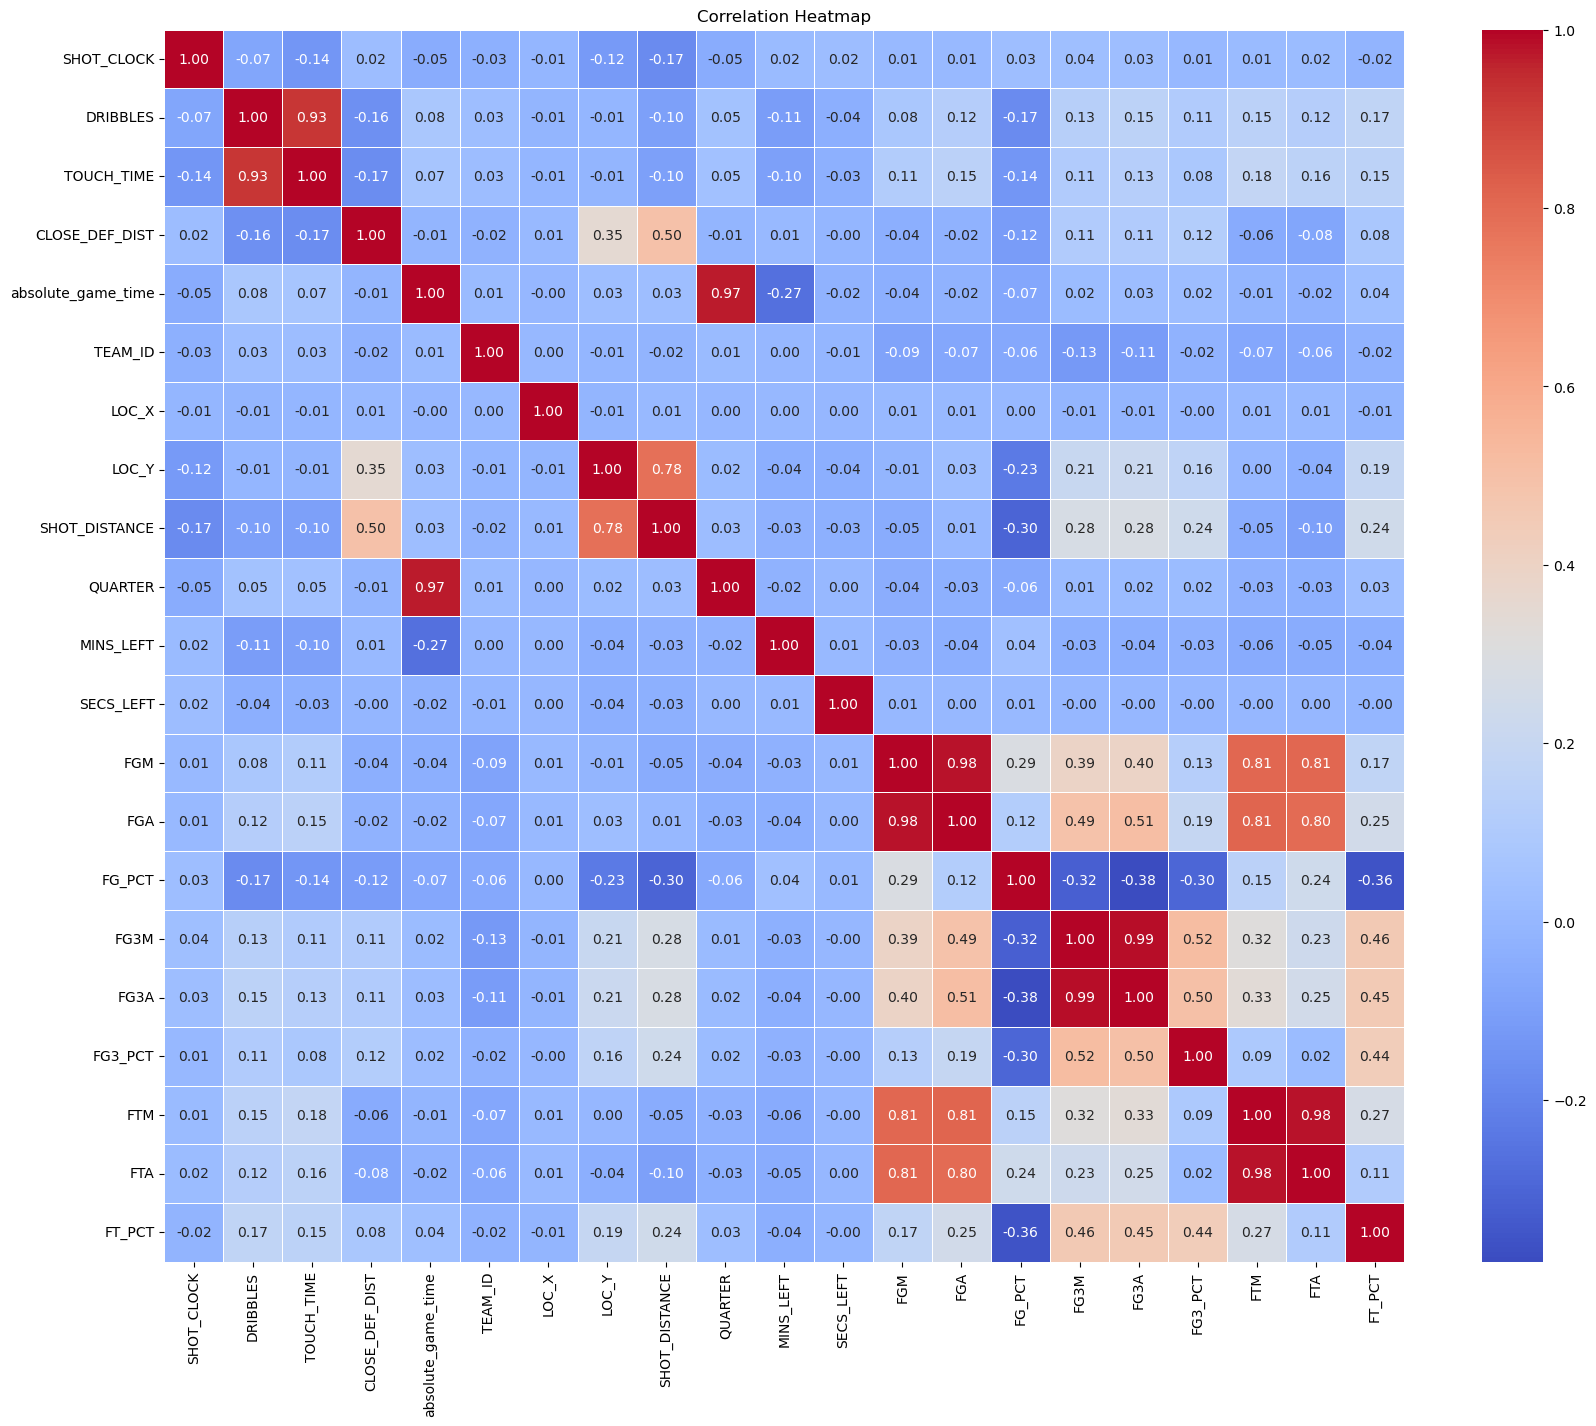

In [40]:
visualize_heatmap(for_pred, numerical_cols)

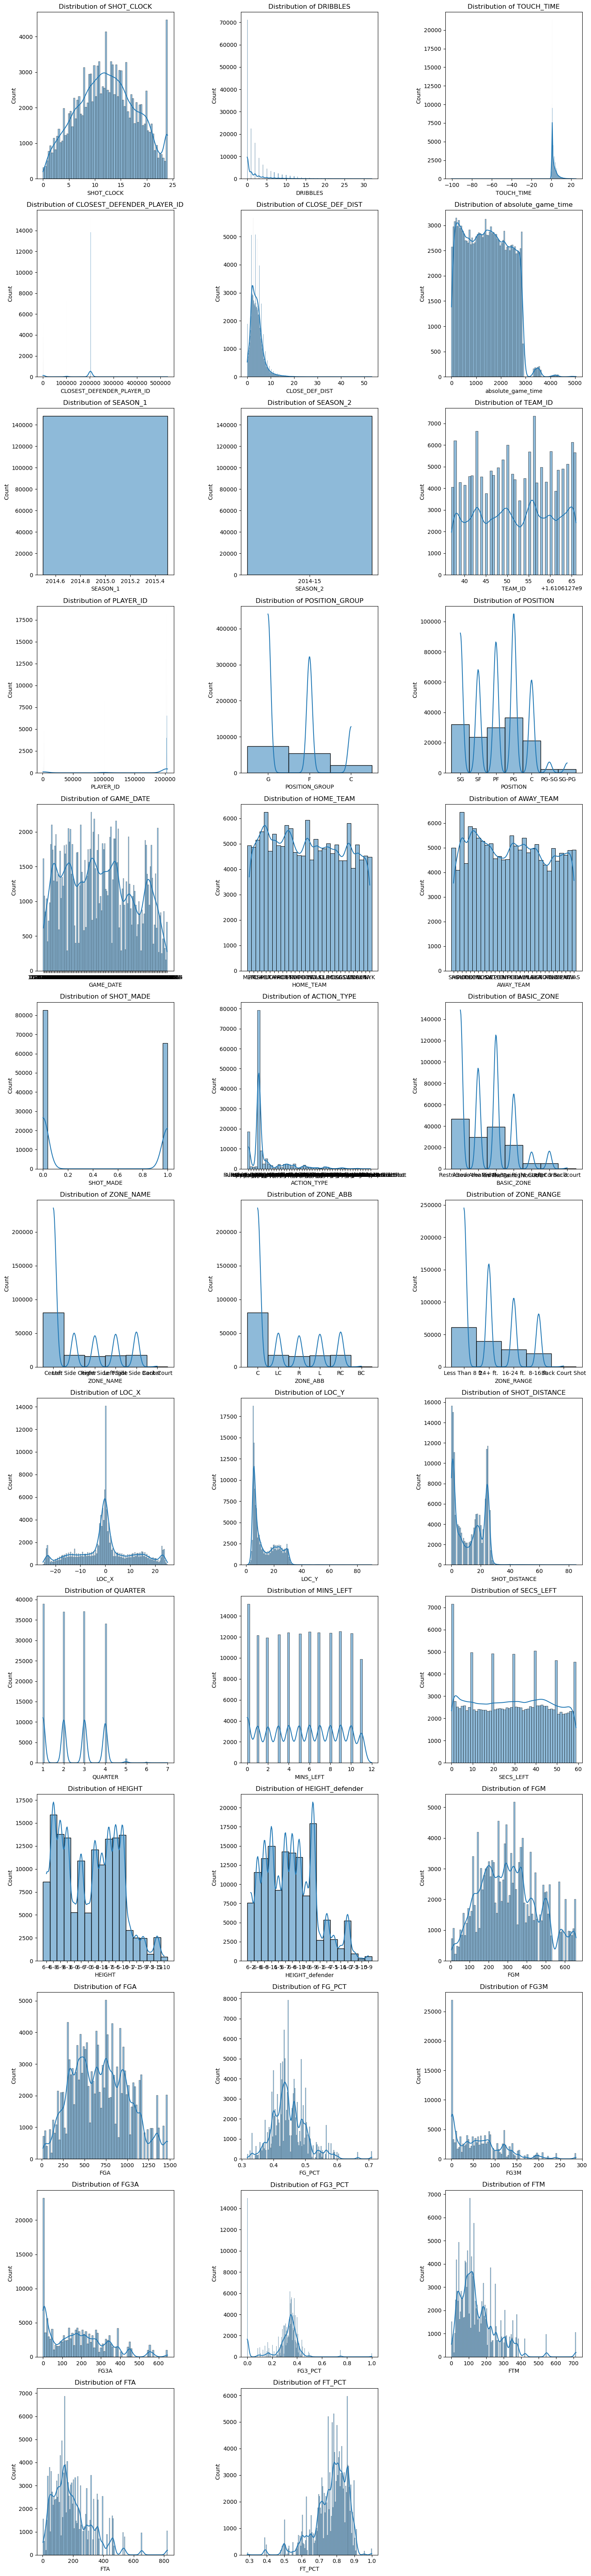

In [41]:
visualize_distributions(for_pred, numerical_cols=for_pred.columns)

In [42]:
importlib.reload(du)
missing_summary = du.missing_values_summary(for_pred)
print(missing_summary)

                 Missing Values  Percentage
SHOT_CLOCK                 6320    4.263731
HEIGHT_defender            3674    2.478631
HEIGHT                      192    0.129531


In [43]:
#Check the empty values in SHOT_CLOCK:
num_empty_shot_clock = kaggle_for_join["SHOT_CLOCK"].isna().sum()
print(f"Number of empty SHOT_CLOCK values: {num_empty_shot_clock}")

Number of empty SHOT_CLOCK values: 5567


In [44]:
# check for duplicate rows in the data for prediction
duplicate_rows = for_pred[for_pred.duplicated()]

# display the duplicate rows
print(duplicate_rows)


        SHOT_CLOCK  DRIBBLES  TOUCH_TIME  CLOSEST_DEFENDER_PLAYER_ID  \
2194          24.0         0         0.0                      101187   
8032          24.0         0         0.0                        2561   
23571         22.5         0         0.0                      201959   
72128         10.0         0         0.0                      202694   
95863         24.0         0         0.0                      203096   
113995         8.5         0         1.0                        2210   
114335        21.5         2         2.5                      201572   
120832        11.6         3         5.7                      203475   
120833        11.6         3         5.7                      203475   
120834        11.6         3         5.7                      203475   
123718        12.0         2         3.3                        2747   
125500        17.0         0         0.9                        2747   
125595        13.5         3         5.7                        

In [45]:
for_pred = for_pred.drop_duplicates().reset_index(drop=True)

In [46]:
importlib.reload(du)
constant_columns = du.find_constant_columns(for_pred)
print("Columns with constant values:", constant_columns)

Found 2 constant columns
Columns with constant values: ['SEASON_1', 'SEASON_2']


In [47]:
# Drop the constant columns
for_pred = for_pred.drop(columns=constant_columns)

In [48]:
for_pred.head()

,SHOT_CLOCK,DRIBBLES,TOUCH_TIME,CLOSEST_DEFENDER_PLAYER_ID,CLOSE_DEF_DIST,absolute_game_time,TEAM_ID,PLAYER_ID,POSITION_GROUP,POSITION,...,HEIGHT_defender,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT
0,22.0,2,1.8,202709,2.3,3.0,1.610613e+09,2754.0,G,SG,...,6-2,225,455,0.495,10,29,0.345,79,126,0.627
1,22.5,2,2.5,201960,3.5,4.0,1.610613e+09,2772.0,F,SF,...,6-6,366,910,0.402,194,555,0.350,122,143,0.853
2,21.8,3,3.2,201565,5.3,4.0,1.610613e+09,202693.0,F,PF,...,6-3,512,1100,0.465,57,179,0.318,177,232,0.763
3,21.1,0,1.3,203095,3.4,4.0,1.610613e+09,203463.0,G,SG,...,6-6,363,831,0.437,140,391,0.358,130,160,0.813
4,20.6,0,0.0,201586,4.0,4.0,1.610613e+09,202693.0,F,PF,...,6-11,512,1100,0.465,57,179,0.318,177,232,0.763


Prepare the data for prediction

In [50]:
target_column = 'SHOT_MADE'

In [51]:
X = for_pred.drop(target_column, axis=1)
y = for_pred[target_column]

In [52]:
X.columns

Index(['SHOT_CLOCK', 'DRIBBLES', 'TOUCH_TIME', 'CLOSEST_DEFENDER_PLAYER_ID',
       'CLOSE_DEF_DIST', 'absolute_game_time', 'TEAM_ID', 'PLAYER_ID',
       'POSITION_GROUP', 'POSITION', 'GAME_DATE', 'HOME_TEAM', 'AWAY_TEAM',
       'ACTION_TYPE', 'BASIC_ZONE', 'ZONE_NAME', 'ZONE_ABB', 'ZONE_RANGE',
       'LOC_X', 'LOC_Y', 'SHOT_DISTANCE', 'QUARTER', 'MINS_LEFT', 'SECS_LEFT',
       'HEIGHT', 'HEIGHT_defender', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A',
       'FG3_PCT', 'FTM', 'FTA', 'FT_PCT'],
      dtype='object')

In [53]:
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

In [54]:
all_columns = set(X.columns)
numerical_and_categorical = set(numerical_cols).union(set(categorical_cols))
other_columns = all_columns - numerical_and_categorical

print("Columns that are not in numerical or categorical:")
print(other_columns)

Columns that are not in numerical or categorical:
set()


In [55]:
# Handle missing values

num_imputer = SimpleImputer(strategy='mean')
X[numerical_cols] = num_imputer.fit_transform(X[numerical_cols])

In [56]:
# Categorical imputer for missing values
cat_imputer = SimpleImputer(strategy='most_frequent')
X[categorical_cols] = cat_imputer.fit_transform(X[categorical_cols])

In [57]:
encoders = {}
for col in categorical_cols:
    encoders[col] = LabelEncoder()
    X[col] = encoders[col].fit_transform(X[col])

In [58]:
# Scale numerical features
scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols]) # zero mean and unit variance for the numerical columns

In [59]:
X.head()

,SHOT_CLOCK,DRIBBLES,TOUCH_TIME,CLOSEST_DEFENDER_PLAYER_ID,CLOSE_DEF_DIST,absolute_game_time,TEAM_ID,PLAYER_ID,POSITION_GROUP,POSITION,...,HEIGHT_defender,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT
0,1.698260,-0.038732,-0.341960,0.552940,-0.658734,-1.678407,1.289308,-1.993054,2,5,...,7,-0.562245,-0.715275,0.866176,-0.952135,-1.026439,0.330812,-0.663418,-0.516568,-1.521742
1,1.787219,-0.038732,-0.112760,0.543423,-0.221244,-1.677231,-0.778393,-1.992825,1,4,...,11,0.360042,0.682676,-0.890106,2.302821,2.556816,0.370084,-0.269539,-0.388781,0.872956
2,1.662676,0.239817,0.116440,0.538405,0.434992,-1.677231,0.485202,0.555559,1,1,...,8,1.315034,1.266436,0.299634,-0.120706,-0.004598,0.118739,0.234258,0.280222,-0.080685
3,1.538132,-0.595831,-0.505674,0.557845,-0.257701,-1.677231,0.714946,0.565374,2,5,...,11,0.340419,0.439955,-0.229139,1.347562,1.439604,0.432921,-0.196260,-0.260994,0.449116
4,1.449172,-0.595831,-0.931332,0.538671,-0.038956,-1.677231,0.485202,0.555559,1,1,...,6,1.315034,1.266436,0.299634,-0.120706,-0.004598,0.118739,0.234258,0.280222,-0.080685


In [60]:
X_train, X_val, X_test, y_train, y_val, y_test = du.split_dataset(X, y, test_size=0.1, validation_size=0.2, random_state=2312)

In [61]:
X_train.columns

Index(['SHOT_CLOCK', 'DRIBBLES', 'TOUCH_TIME', 'CLOSEST_DEFENDER_PLAYER_ID',
       'CLOSE_DEF_DIST', 'absolute_game_time', 'TEAM_ID', 'PLAYER_ID',
       'POSITION_GROUP', 'POSITION', 'GAME_DATE', 'HOME_TEAM', 'AWAY_TEAM',
       'ACTION_TYPE', 'BASIC_ZONE', 'ZONE_NAME', 'ZONE_ABB', 'ZONE_RANGE',
       'LOC_X', 'LOC_Y', 'SHOT_DISTANCE', 'QUARTER', 'MINS_LEFT', 'SECS_LEFT',
       'HEIGHT', 'HEIGHT_defender', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A',
       'FG3_PCT', 'FTM', 'FTA', 'FT_PCT'],
      dtype='object')

In [62]:
X_train.dropna()

,SHOT_CLOCK,DRIBBLES,TOUCH_TIME,CLOSEST_DEFENDER_PLAYER_ID,CLOSE_DEF_DIST,absolute_game_time,TEAM_ID,PLAYER_ID,POSITION_GROUP,POSITION,...,HEIGHT_defender,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT
124740,1.484756,0.518367,0.443869,-1.992167,-1.278512,1.160592,-0.548649,0.535967,2,5,...,5,-0.895838,-0.650754,-1.569957,0.339234,0.308767,0.519321,-0.177940,-0.351196,1.286200
102827,-0.009769,-0.595831,-0.702132,0.548061,0.143332,0.629015,-0.778393,-2.004055,2,5,...,12,-0.804264,-0.742927,-0.512411,1.099903,0.976369,0.684266,-1.029816,-1.102884,0.449116
93034,1.769427,-0.317282,-0.145503,0.538557,-1.132682,0.402036,-1.008138,0.551684,0,0,...,16,0.019908,-0.374236,1.999261,-1.093655,-1.183121,0.236557,0.032739,0.159952,-0.557505
100347,0.630742,-0.595831,-0.669389,0.533297,2.148495,0.570212,0.714946,0.565374,2,5,...,13,0.340419,0.439955,-0.229139,1.347562,1.439604,0.432921,-0.196260,-0.260994,0.449116
113846,0.986581,1.075466,1.000498,0.533284,0.544364,0.888923,1.633925,0.551697,2,5,...,11,-1.098611,-0.890403,-1.702150,-0.439125,-0.317962,-0.077625,-0.580978,-0.696973,0.978916
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117821,-1.842342,-0.038732,-0.145503,-1.991786,-0.585819,0.988888,0.600074,-1.995667,0,0,...,14,-0.182864,-0.426467,1.243871,-1.129035,-1.223995,-2.379008,-0.727537,-0.696973,-0.684657
120281,-0.739240,-0.595831,-0.865846,0.557629,-0.367074,1.050042,-1.697372,0.535801,0,0,...,9,1.360822,0.851659,1.678220,-0.934445,-0.978753,0.024484,-0.406939,-0.403814,-0.123069
113931,-0.383401,-0.595831,-0.276474,0.533132,-0.549361,0.891275,0.714946,0.536158,1,1,...,16,-0.791182,-0.979503,1.243871,-1.129035,-1.223995,-2.379008,-0.260379,-0.336163,0.523288
13622,0.346070,-0.595831,-0.505674,0.552635,0.033959,-1.384393,-1.467627,0.551684,0,0,...,14,0.019908,-0.374236,1.999261,-1.093655,-1.183121,0.236557,0.032739,0.159952,-0.557505


In [63]:
y_train = y_train.astype(int)
y_val = y_val.astype(int)
y_test = y_test.astype(int)

MODELS:

LOGISTIC REGRESSION

In [66]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix

# Initialize the logistic regression model with L2 regularization
logistic_model_l2 = LogisticRegression(max_iter=1000, random_state=2312)
logistic_model_l1 = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000, random_state=2312)

# Fit the model on the training data
logistic_model_l2.fit(X_train, y_train)
logistic_model_l1.fit(X_train, y_train)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000, penalty='l1', random_state=2312,
                   solver='liblinear')

In [67]:
print(logistic_model_l2.score(X_train, y_train),logistic_model_l1.score(X_train, y_train))

0.6185946695655433 0.6186977546200847


In [68]:
y_val_pred_l2 = logistic_model_l2.predict(X_val)
y_val_pred_l1 = logistic_model_l1.predict(X_val)

In [69]:
y_test_pred_l2 = logistic_model_l2.predict(X_test)
y_test_pred_l1 = logistic_model_l1.predict(X_test)

In [70]:
accuracy_score(y_test, y_test_pred_l2), accuracy_score(y_test, y_test_pred_l1)

(0.6147358477835504, 0.615410566088658)

In [71]:
accuracy_score(y_val, y_val_pred_l2), accuracy_score(y_val, y_val_pred_l1)

(0.6179480451325111, 0.6177981032349964)

Accuracy: 0.6179
Precision: 0.5917
Recall: 0.4327
F1 Score: 0.4999
ROC AUC: 0.5985


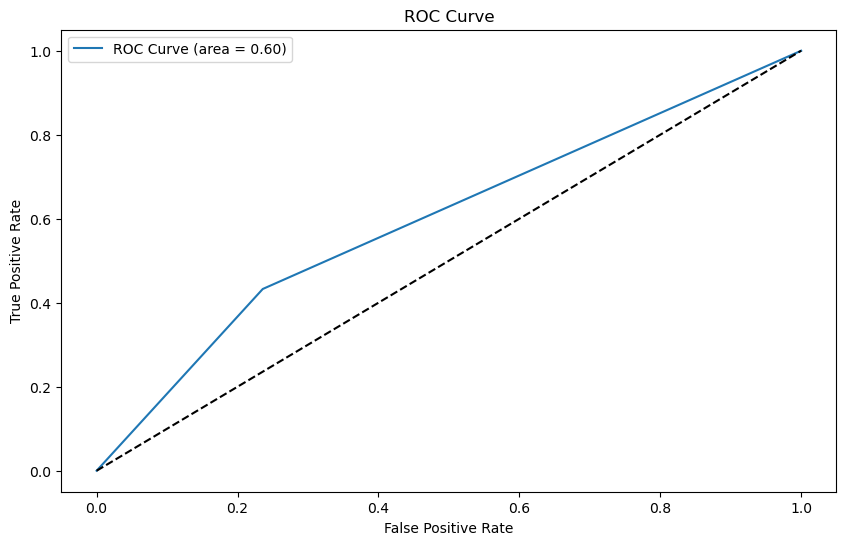

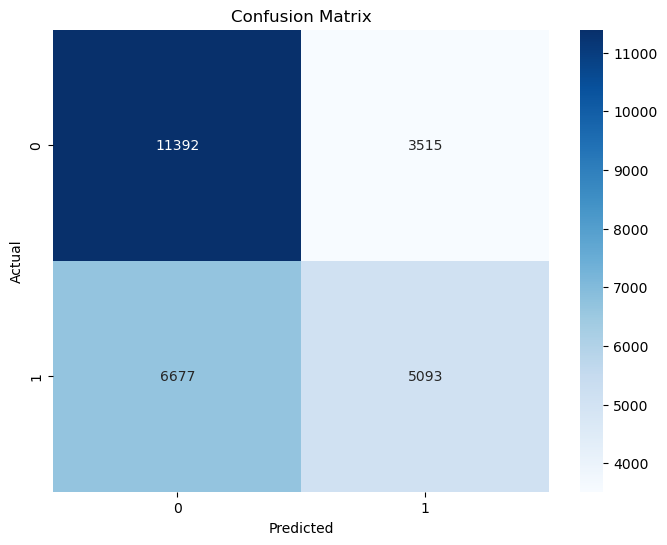

In [72]:
# Calculate metrics for l2
accuracy = accuracy_score(y_val, y_val_pred_l2)
precision = precision_score(y_val, y_val_pred_l2)
recall = recall_score(y_val, y_val_pred_l2)
f1 = f1_score(y_val, y_val_pred_l2)
roc_auc = roc_auc_score(y_val, y_val_pred_l2)

# Print metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

# Plot ROC curve
fpr, tpr, _ = roc_curve(y_val, y_val_pred_l2)
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='best')
plt.show()

# Plot confusion matrix
conf_matrix = confusion_matrix(y_val, y_val_pred_l2)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Accuracy: 0.6178
Precision: 0.5913
Recall: 0.4329
F1 Score: 0.4999
ROC AUC: 0.5983


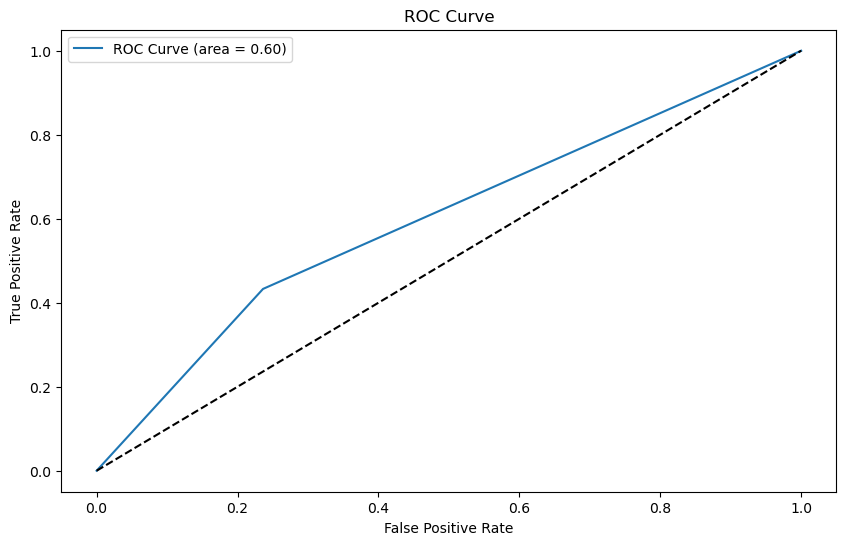

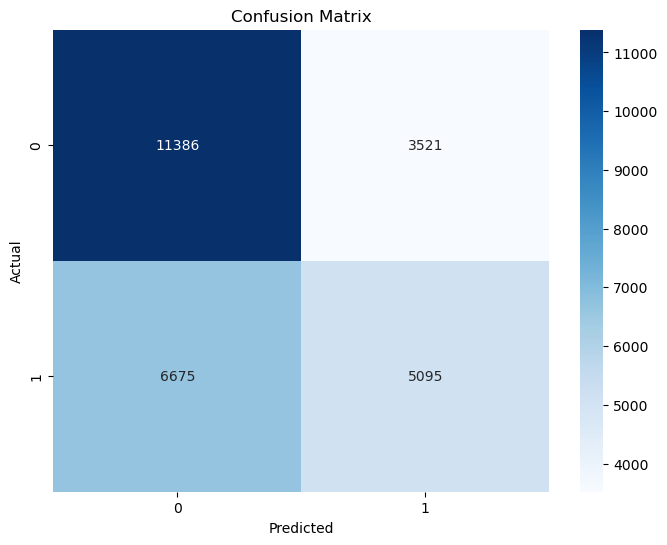

In [73]:
# Calculate metrics for l1
accuracy = accuracy_score(y_val, y_val_pred_l1)
precision = precision_score(y_val, y_val_pred_l1)
recall = recall_score(y_val, y_val_pred_l1)
f1 = f1_score(y_val, y_val_pred_l1)
roc_auc = roc_auc_score(y_val, y_val_pred_l1)

# Print metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

# Plot ROC curve
fpr, tpr, _ = roc_curve(y_val, y_val_pred_l1)
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='best')
plt.show()

# Plot confusion matrix
conf_matrix = confusion_matrix(y_val, y_val_pred_l1)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [74]:
y_test_pred_l2 = logistic_model_l2.predict(X_test)
y_test_pred_l1 = logistic_model_l1.predict(X_test)

In [75]:
y_test_proba_l2 = logistic_model_l2.predict_proba(X_test)[:, 1]
y_test_proba_l1 = logistic_model_l1.predict_proba(X_test)[:, 1]

In [76]:
accuracy_l2 = accuracy_score(y_test, y_test_pred_l2)
precision_l2 = precision_score(y_test, y_test_pred_l2)
recall_l2 = recall_score(y_test, y_test_pred_l2)
f1_l2 = f1_score(y_test, y_test_pred_l2)
roc_auc_l2 = roc_auc_score(y_test, y_test_proba_l2)

In [77]:
print("\n📊 **Logistic Regression - L2 Regularization** 📊")
print(f"Accuracy: {accuracy_l2:.4f}")
print(f"Precision: {precision_l2:.4f}")
print(f"Recall: {recall_l2:.4f}")
print(f"F1 Score: {f1_l2:.4f}")
print(f"ROC AUC: {roc_auc_l2:.4f}")


📊 **Logistic Regression - L2 Regularization** 📊
Accuracy: 0.6147
Precision: 0.5913
Recall: 0.4423
F1 Score: 0.5061
ROC AUC: 0.6307


In [78]:
fpr_l2, tpr_l2, _ = roc_curve(y_test, y_test_proba_l2)

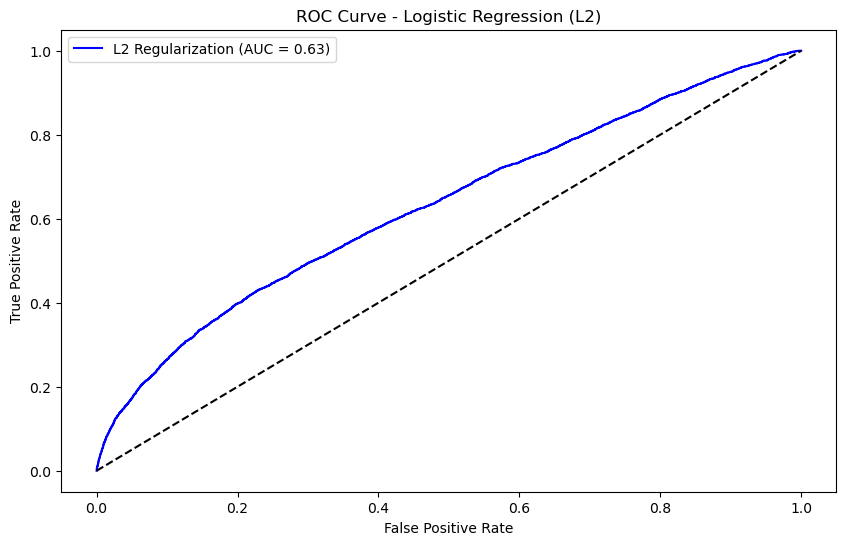

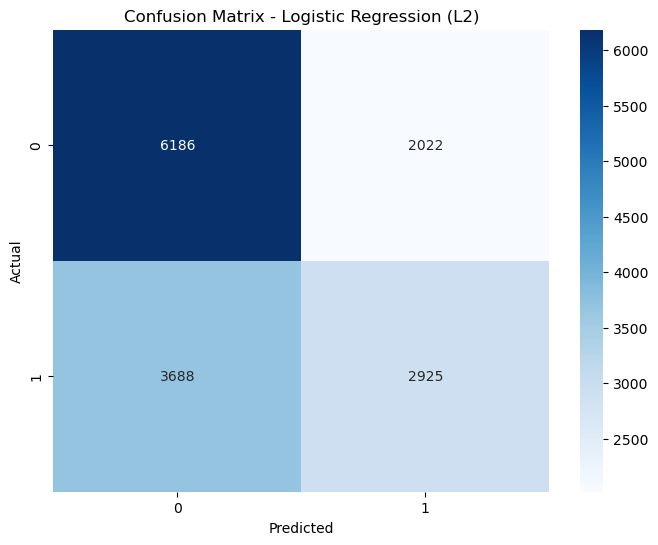

In [79]:
plt.figure(figsize=(10, 6))
plt.plot(fpr_l2, tpr_l2, label=f'L2 Regularization (AUC = {roc_auc_l2:.2f})', color='blue')
plt.plot([0, 1], [0, 1], 'k--')  # קו אקראי
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression (L2)')
plt.legend(loc='best')
plt.show()


conf_matrix_l2 = confusion_matrix(y_test, y_test_pred_l2)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_l2, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression (L2)')
plt.show()

In [80]:
accuracy_l1 = accuracy_score(y_test, y_test_pred_l1)
precision_l1 = precision_score(y_test, y_test_pred_l1)
recall_l1 = recall_score(y_test, y_test_pred_l1)
f1_l1 = f1_score(y_test, y_test_pred_l1)
roc_auc_l1 = roc_auc_score(y_test, y_test_proba_l1)

In [81]:
print("\n📊 **Logistic Regression - L1 Regularization** 📊")
print(f"Accuracy: {accuracy_l1:.4f}")
print(f"Precision: {precision_l1:.4f}")
print(f"Recall: {recall_l1:.4f}")
print(f"F1 Score: {f1_l1:.4f}")
print(f"ROC AUC: {roc_auc_l1:.4f}")


📊 **Logistic Regression - L1 Regularization** 📊
Accuracy: 0.6154
Precision: 0.5924
Recall: 0.4426
F1 Score: 0.5067
ROC AUC: 0.6307


In [82]:
fpr_l1, tpr_l1, _ = roc_curve(y_test, y_test_proba_l1)

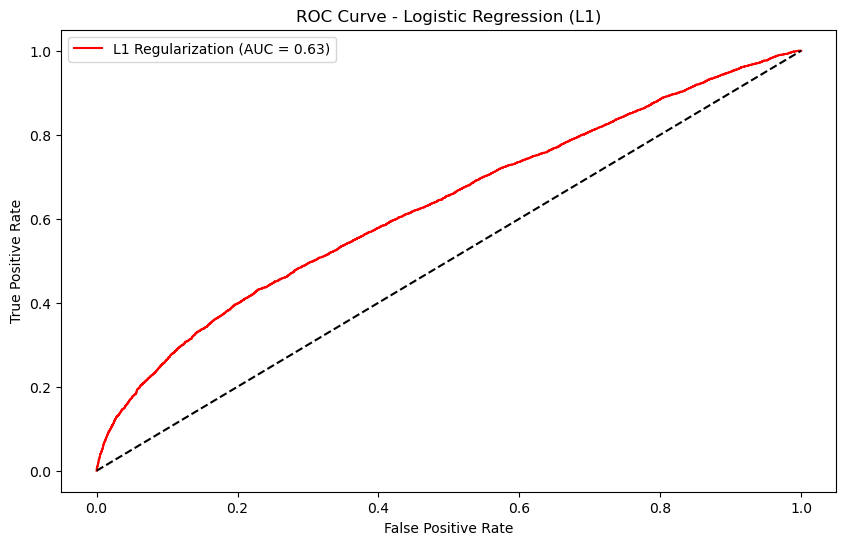

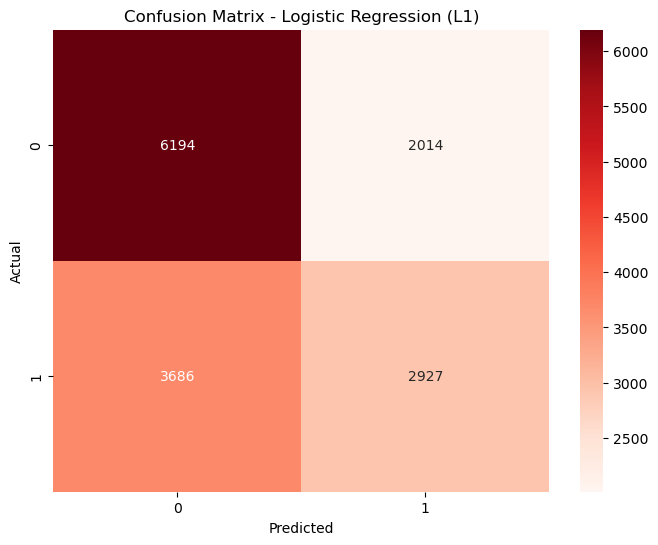

In [83]:
plt.figure(figsize=(10, 6))
plt.plot(fpr_l1, tpr_l1, label=f'L1 Regularization (AUC = {roc_auc_l1:.2f})', color='red')
plt.plot([0, 1], [0, 1], 'k--')  # קו אקראי
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression (L1)')
plt.legend(loc='best')
plt.show()


conf_matrix_l1 = confusion_matrix(y_test, y_test_pred_l1)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_l1, annot=True, fmt='d', cmap='Reds')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression (L1)')
plt.show()

SVM

In [85]:
# check the class balance. if balanced, we don't need to use class_weight='balanced'
y.value_counts()

SHOT_MADE
False    82717
True     65489
Name: count, dtype: int64

In [86]:
from sklearn import svm

# Initialize the SVM model
svm_model = svm.SVC(random_state=2312, cache_size=800)

In [87]:
svm_model.fit(X_train, y_train)

SVC(cache_size=800, random_state=2312)

In [88]:
#svm_model.score(X_train, y_train)

In [89]:
svm_val_pred = svm_model.predict(X_val)

In [90]:
svm_val_pred

array([0, 0, 1, ..., 0, 1, 0])

In [91]:
accuracy = accuracy_score(y_val, svm_val_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.6169


Accuracy: 0.6169
Precision: 0.6677
Recall: 0.2621
F1 Score: 0.3764
ROC AUC: 0.5796


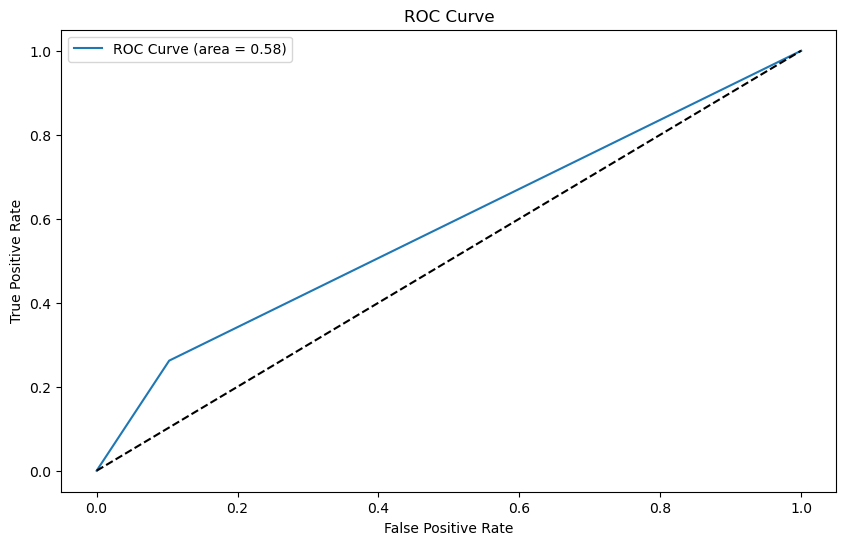

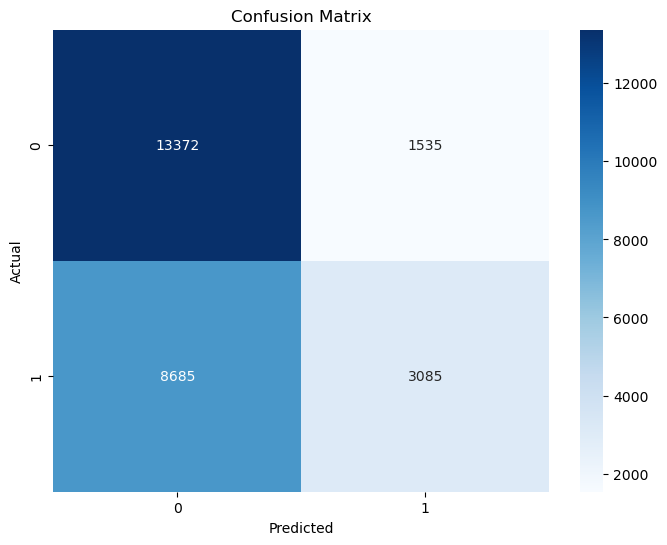

In [92]:
accuracy = accuracy_score(y_val, svm_val_pred)
precision = precision_score(y_val, svm_val_pred)
recall = recall_score(y_val, svm_val_pred)
f1 = f1_score(y_val, svm_val_pred)
roc_auc = roc_auc_score(y_val, svm_val_pred)

# Print metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

# Plot ROC curve
fpr, tpr, _ = roc_curve(y_val, svm_val_pred)
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='best')
plt.show()

# Plot confusion matrix
conf_matrix = confusion_matrix(y_val, svm_val_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [93]:
svm_test_pred = svm_model.predict(X_test)

In [94]:
accuracy = accuracy_score(y_test, svm_test_pred)
precision = precision_score(y_test, svm_test_pred)
recall = recall_score(y_test, svm_test_pred)
f1 = f1_score(y_test, svm_test_pred)
roc_auc = roc_auc_score(y_test, svm_test_pred)

# Print metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

Accuracy: 0.6142
Precision: 0.6675
Recall: 0.2696
F1 Score: 0.3841
ROC AUC: 0.5807


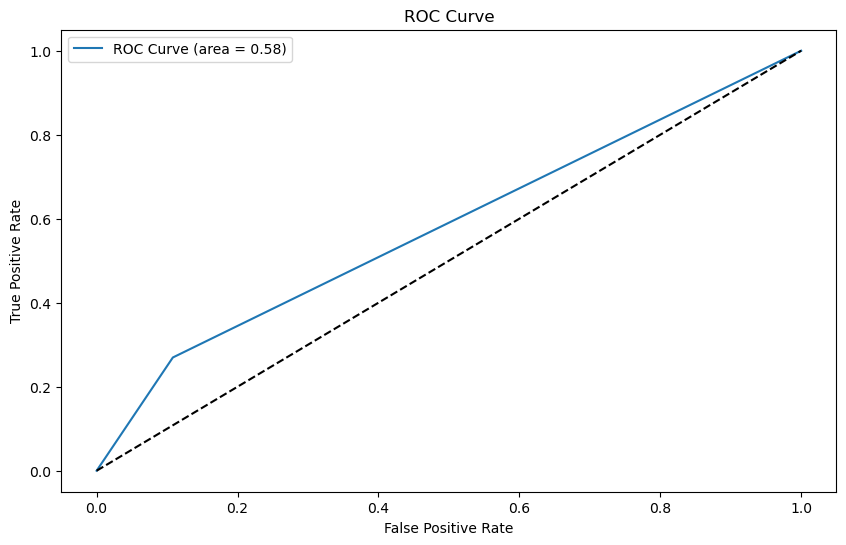

In [95]:
#Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, svm_test_pred)
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='best')
plt.show()

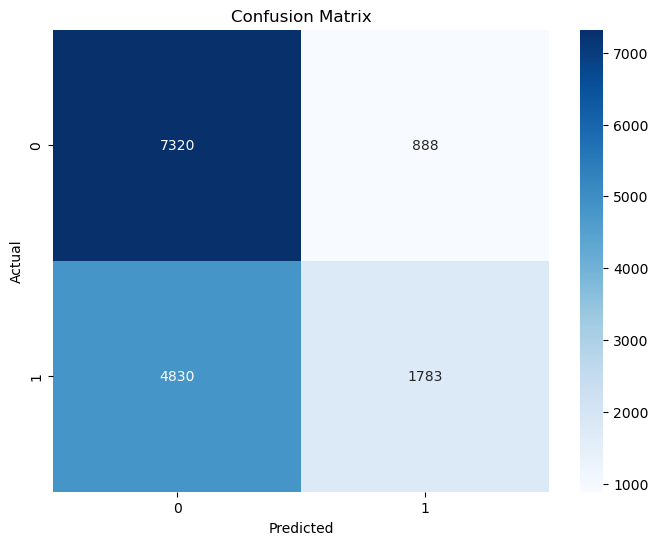

In [96]:

# Plot confusion matrix
conf_matrix = confusion_matrix(y_test, svm_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [97]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = [
  {'C': [1, 10, 100, 1000], 'kernel': ['linear']},
  {'C': [1, 10, 100, 1000], 'gamma': [0.001, 0.0001], 'kernel': ['rbf']},
 ]

# Initialize the GridSearchCV object
#  -  grid_search = GridSearchCV(svm_model, param_grid, refit=True, verbose=2, cv=5, n_jobs=-1)

# Fit the grid search to the data
#  -  grid_search.fit(X_train, y_train)

In [98]:
#grid_search_results = pd.DataFrame(grid_search.cv_results_)

In [99]:
# Print the best parameters and best score
#  print(f"Best Parameters: {grid_search.best_params_}")
#  print(f"Best Score: {grid_search.best_score_}")

# Update the svm_model with the best parameters
#  best_svm_model = grid_search.best_estimator_

In [100]:
#best_svm_model = grid_search.best_estimator_
#best_svm_model.fit(X_train, y_train)


In [101]:
#svm_grid_test_pred = best_svm_model.predict(X_test)

RANDOM FOREST

In [104]:
from sklearn.ensemble import RandomForestClassifier
random_forest_model = RandomForestClassifier(random_state=2312, n_estimators=200)

In [105]:
random_forest_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=2312)

In [106]:
val_rf_pred = random_forest_model.predict(X_val)

In [107]:
accuracy = accuracy_score(y_val, val_rf_pred)
precision = precision_score(y_val, val_rf_pred)
recall = recall_score(y_val, val_rf_pred)
f1 = f1_score(y_val, val_rf_pred)
roc_auc = roc_auc_score(y_val, val_rf_pred)

# Print metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

Accuracy: 0.7168
Precision: 0.7531
Recall: 0.5329
F1 Score: 0.6241
ROC AUC: 0.6975


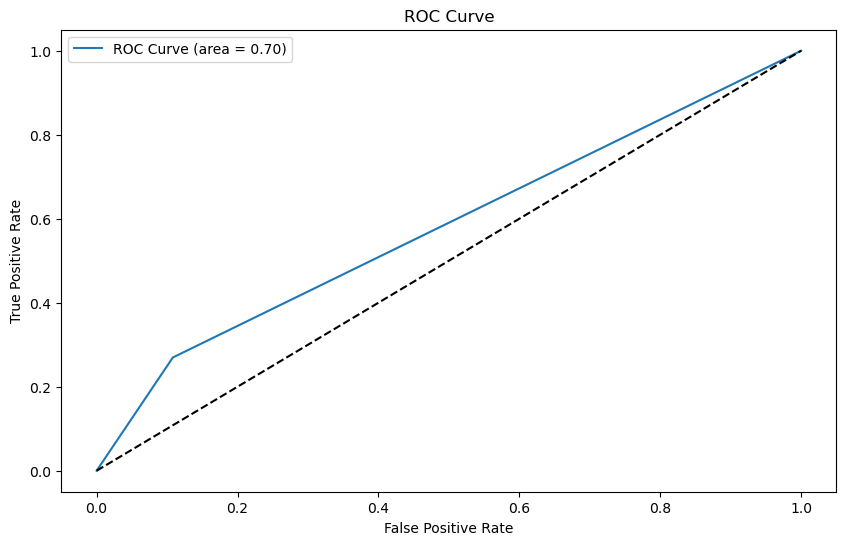

In [108]:
#Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, svm_test_pred)
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='best')
plt.show()

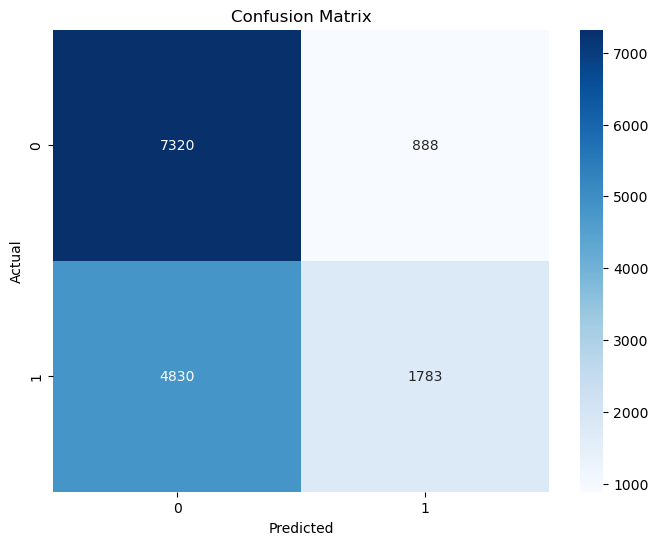

In [109]:

# Plot confusion matrix
conf_matrix = confusion_matrix(y_test, svm_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

/var/folders/fh/lr2n8w4x2hlcn416x09v4d6m0000gn/T/ipykernel_64165/785036201.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importances, palette='viridis')


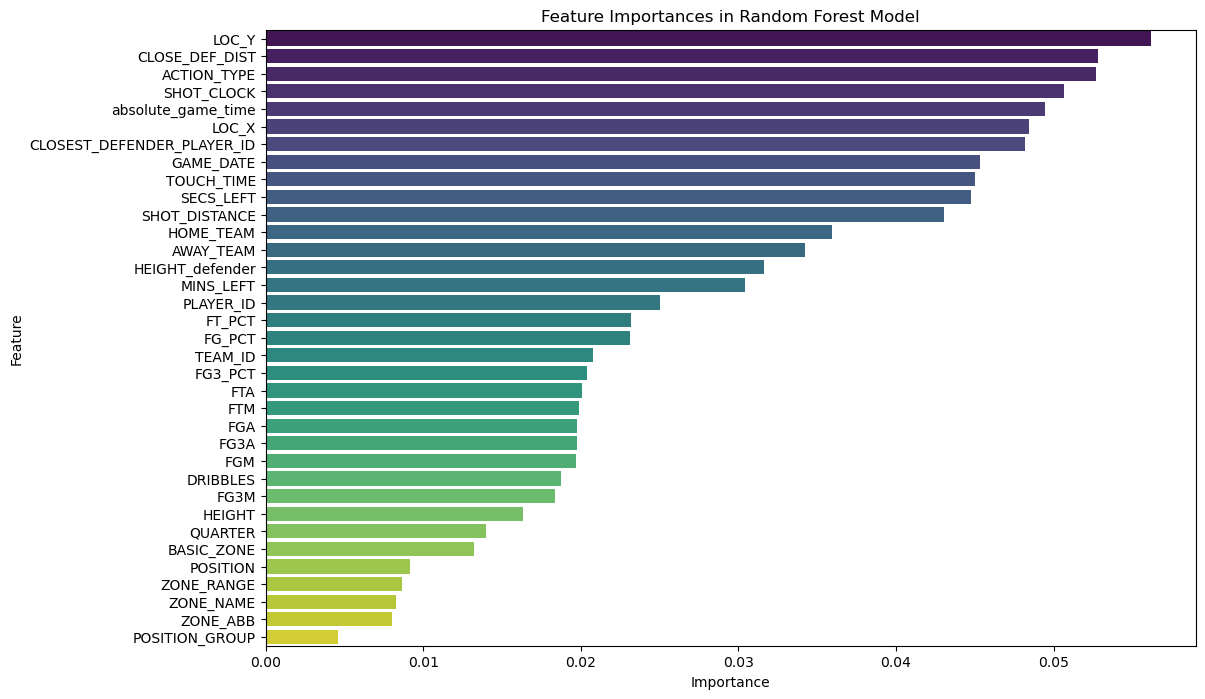

In [110]:
# Get feature importances from the random forest model
importances = random_forest_model.feature_importances_

# Create a DataFrame for better visualization
feature_importances = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances})

# Sort the DataFrame by importance
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importances, palette='viridis')
plt.title('Feature Importances in Random Forest Model')
plt.show()

In [111]:
y_test_pred_rf = random_forest_model.predict(X_test)

In [112]:
accuracy_rf = accuracy_score(y_test, y_test_pred_rf)
precision_rf = precision_score(y_test, y_test_pred_rf)
recall_rf = recall_score(y_test, y_test_pred_rf)
f1_rf = f1_score(y_test, y_test_pred_rf)
roc_auc_rf = roc_auc_score(y_test, random_forest_model.predict_proba(X_test)[:, 1])

In [113]:
print("\n📊 **Random Forest - Test Metrics** 📊")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1 Score: {f1_rf:.4f}")
print(f"ROC AUC: {roc_auc_rf:.4f}")


📊 **Random Forest - Test Metrics** 📊
Accuracy: 0.7140
Precision: 0.7537
Recall: 0.5332
F1 Score: 0.6246
ROC AUC: 0.7809


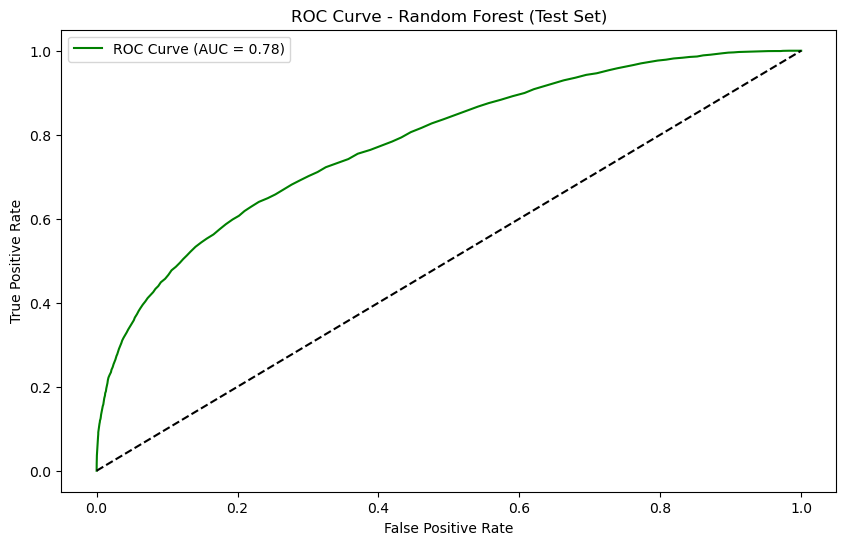

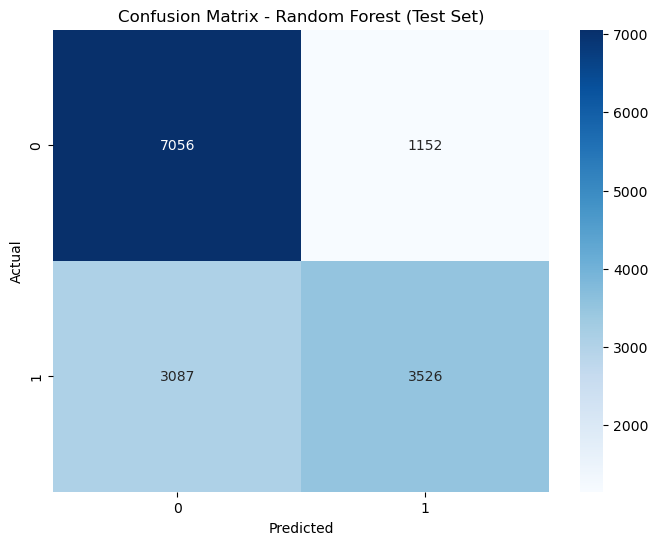

In [114]:
# עקומת ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, random_forest_model.predict_proba(X_test)[:, 1])
plt.figure(figsize=(10, 6))
plt.plot(fpr_rf, tpr_rf, label=f'ROC Curve (AUC = {roc_auc_rf:.2f})', color='green')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest (Test Set)')
plt.legend(loc='best')
plt.show()

# מטריצת בלבול
conf_matrix_rf = confusion_matrix(y_test, y_test_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest (Test Set)')
plt.show()

NAIVE BAYES

In [116]:
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, classification_report

In [117]:
#Naive bayes model
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

GaussianNB()

In [118]:
y_pred_nb = nb_model.predict(X_val)

In [119]:
accuracy = accuracy_score(y_val, y_pred_nb)
precision = precision_score(y_val, y_pred_nb)
recall = recall_score(y_val, y_pred_nb)
f1 = f1_score(y_val, y_pred_nb)
roc_auc = roc_auc_score(y_val, nb_model.predict_proba(X_val)[:, 1])
report = classification_report(y_val, y_pred_nb)

In [120]:
print("\n📊 **Naive Bayes - Metrics** 📊")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print('Classification Report:')
print(report)


📊 **Naive Bayes - Metrics** 📊
Accuracy: 0.5838
Precision: 0.5267
Recall: 0.5598
F1 Score: 0.5428
ROC AUC: 0.6164
Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.60      0.62     14907
           1       0.53      0.56      0.54     11770

    accuracy                           0.58     26677
   macro avg       0.58      0.58      0.58     26677
weighted avg       0.59      0.58      0.58     26677



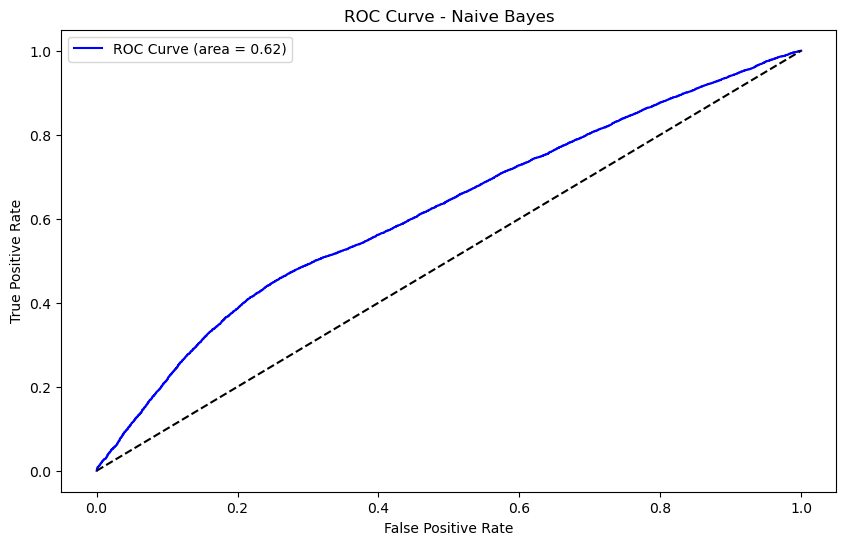

In [121]:
fpr, tpr, _ = roc_curve(y_val, nb_model.predict_proba(X_val)[:, 1])
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (area = {roc_auc:.2f})', color='blue')
plt.plot([0, 1], [0, 1], 'k--')  # קו אקראי
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Naive Bayes')
plt.legend(loc='best')
plt.show()

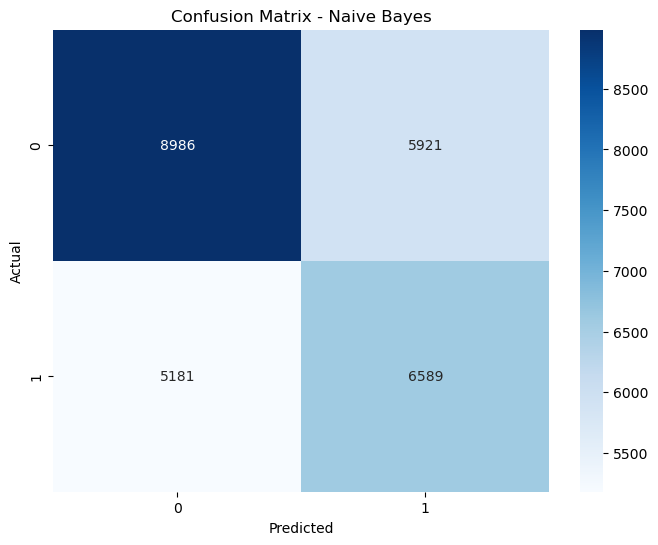

In [122]:
conf_matrix = confusion_matrix(y_val, y_pred_nb)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Naive Bayes')
plt.show()

In [123]:
y_test_pred_nb = nb_model.predict(X_test)

In [124]:
accuracy_test = accuracy_score(y_test, y_test_pred_nb)
precision_test = precision_score(y_test, y_test_pred_nb)
recall_test = recall_score(y_test, y_test_pred_nb)
f1_test = f1_score(y_test, y_test_pred_nb)
roc_auc_test = roc_auc_score(y_test, nb_model.predict_proba(X_test)[:, 1])

In [125]:
print("\n📊 **Naive Bayes - Test Metrics** 📊")
print(f"Accuracy: {accuracy_test:.4f}")
print(f"Precision: {precision_test:.4f}")
print(f"Recall: {recall_test:.4f}")
print(f"F1 Score: {f1_test:.4f}")
print(f"ROC AUC: {roc_auc_test:.4f}")


📊 **Naive Bayes - Test Metrics** 📊
Accuracy: 0.5879
Precision: 0.5360
Recall: 0.5695
F1 Score: 0.5522
ROC AUC: 0.6219


In [126]:
y_test_proba_nb = nb_model.predict_proba(X_test)[:, 1]

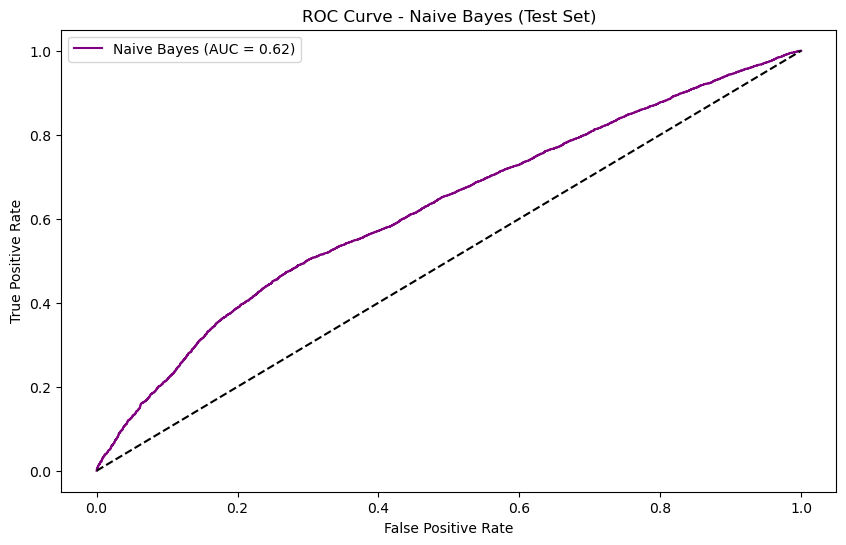

In [127]:
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_test_proba_nb)
roc_auc_nb = roc_auc_score(y_test, y_test_proba_nb)

# ציור עקומת ROC
plt.figure(figsize=(10, 6))
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC = {roc_auc_nb:.2f})', color='purple')
plt.plot([0, 1], [0, 1], 'k--')  # קו אקראי
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Naive Bayes (Test Set)')
plt.legend(loc='best')
plt.show()

In [128]:
y_test_pred_nb = nb_model.predict(X_test)

In [129]:
#Creat confusion matrix:
conf_matrix_nb = confusion_matrix(y_test, y_test_pred_nb)

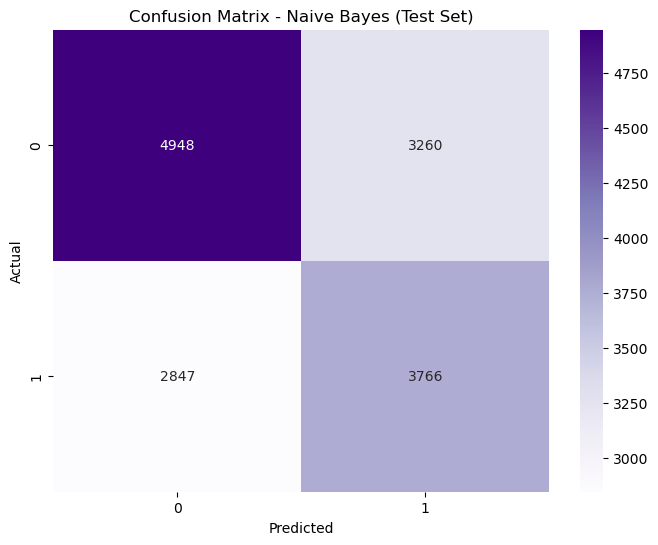

In [130]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_nb, annot=True, fmt='d', cmap='Purples')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Naive Bayes (Test Set)')
plt.show()

XGBOOST

In [132]:
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix

In [133]:
# Creat model XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,  # מספר עצים
    learning_rate=0.1,  # קצב הלמידה
    max_depth=6,  # עומק העצים
    subsample=0.8,  # שימוש ב-80% מהדאטה בכל עץ
    colsample_bytree=0.8,  # שימוש ב-80% מהמשתנים בכל עץ
    random_state=42
)

In [134]:
# Convert format:
X_train = X_train.values
X_val = X_val.values
X_test = X_test.values
y_train = y_train.values
y_val = y_val.values
y_test = y_test.values

In [135]:
# אימון המודל עם XGBoost
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [136]:
# חיזוי על סט הבדיקה
y_pred_xgb = xgb_model.predict(X_val)

In [137]:
accuracy = accuracy_score(y_val, y_pred_xgb)
precision = precision_score(y_val, y_pred_xgb)
recall = recall_score(y_val, y_pred_xgb)
f1 = f1_score(y_val, y_pred_xgb)
roc_auc = roc_auc_score(y_val, xgb_model.predict_proba(X_val)[:, 1])
report = classification_report(y_val, y_pred_xgb)

In [138]:
print("\n📊 **XGBoost - Metrics** 📊")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print('Classification Report:')
print(report)


📊 **XGBoost - Metrics** 📊
Accuracy: 0.6768
Precision: 0.7027
Recall: 0.4636
F1 Score: 0.5587
ROC AUC: 0.7291
Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.85      0.75     14907
           1       0.70      0.46      0.56     11770

    accuracy                           0.68     26677
   macro avg       0.68      0.65      0.65     26677
weighted avg       0.68      0.68      0.66     26677



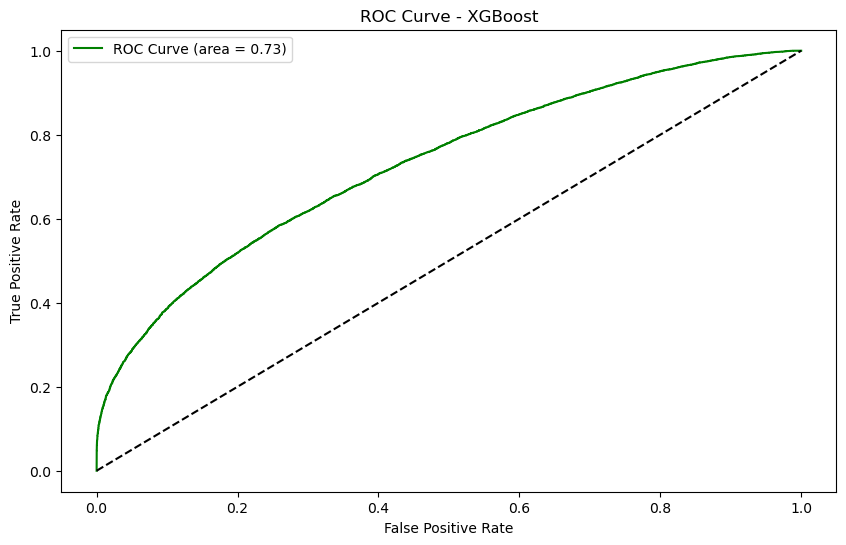

In [139]:
fpr, tpr, _ = roc_curve(y_val, xgb_model.predict_proba(X_val)[:, 1])
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (area = {roc_auc:.2f})', color='green')
plt.plot([0, 1], [0, 1], 'k--')  # קו אקראי
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend(loc='best')
plt.show()

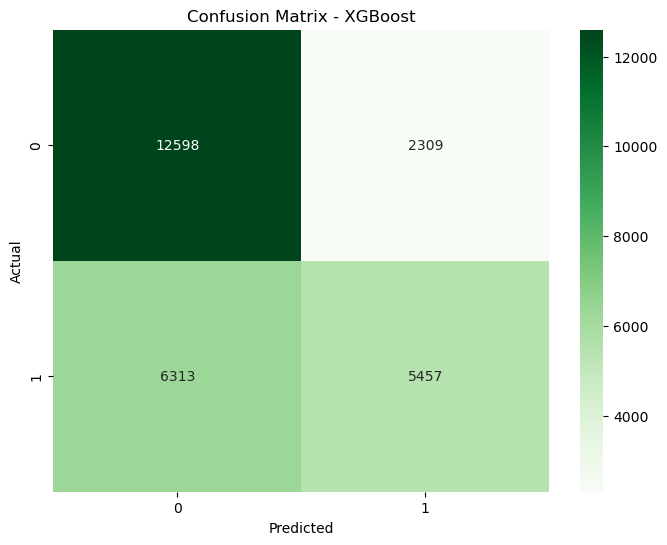

In [140]:
conf_matrix = confusion_matrix(y_val, y_pred_xgb)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost')
plt.show()

In [141]:
y_test_pred_xgb = xgb_model.predict(X_test)

In [142]:
y_test_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [143]:
accuracy_xgb = accuracy_score(y_test, y_test_pred_xgb)
precision_xgb = precision_score(y_test, y_test_pred_xgb)
recall_xgb = recall_score(y_test, y_test_pred_xgb)
f1_xgb = f1_score(y_test, y_test_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_test_proba_xgb)

In [144]:
print("\n📊 **XGBoost - Test Set Metrics** 📊")
print(f"Accuracy: {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall: {recall_xgb:.4f}")
print(f"F1 Score: {f1_xgb:.4f}")
print(f"ROC AUC: {roc_auc_xgb:.4f}")


📊 **XGBoost - Test Set Metrics** 📊
Accuracy: 0.6715
Precision: 0.6995
Recall: 0.4624
F1 Score: 0.5568
ROC AUC: 0.7258


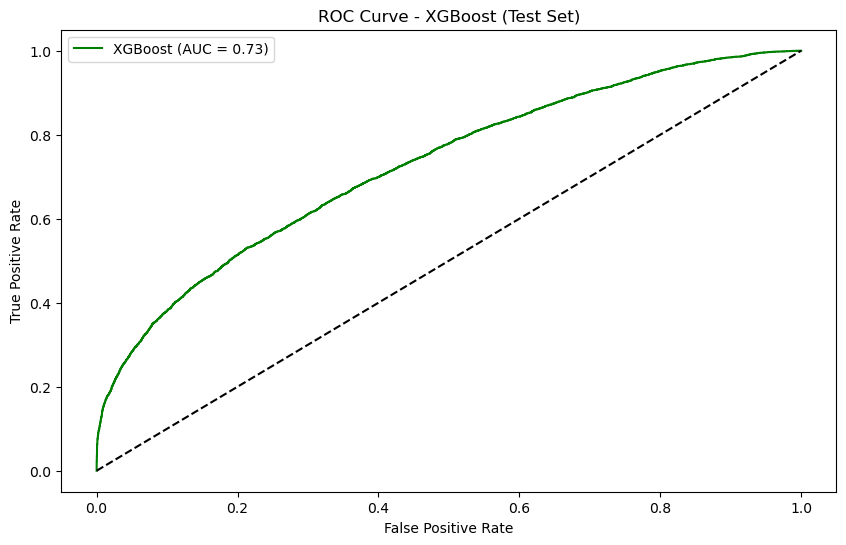

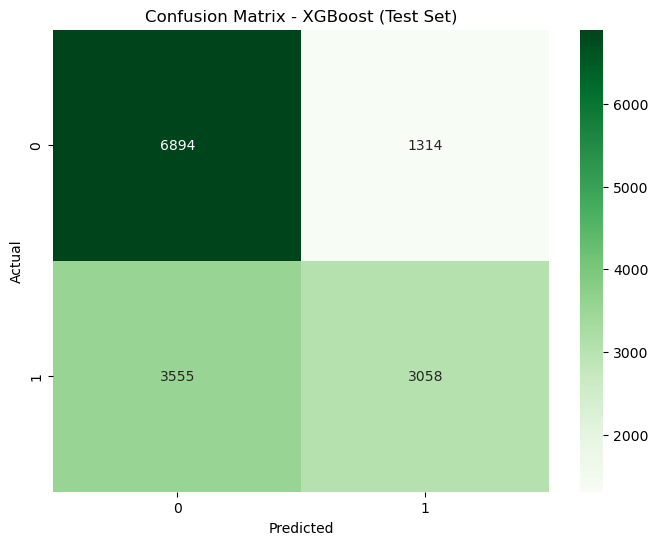

In [145]:
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_test_proba_xgb)

plt.figure(figsize=(10, 6))
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_xgb:.2f})', color='green')
plt.plot([0, 1], [0, 1], 'k--')  # קו אקראי
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost (Test Set)')
plt.legend(loc='best')
plt.show()

conf_matrix_xgb = confusion_matrix(y_test, y_test_pred_xgb)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_xgb, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost (Test Set)')
plt.show()